In [1]:
# Install dependencies
%pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import re
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
df = pd.read_csv("../data/raw/training_data.csv")
df = df.dropna(subset=["text"])

In [4]:
pattern = re.compile(r'[^a-zA-Z\s]+')
noise_pattern = re.compile(r'escapenumber|escapelong', re.IGNORECASE)
stopwords = {'y', 'did', 'i', 'again', "hadn't", 'my', 'over', 'too', 'here', "that'll", 'couldn', 'than', "they've", 'same', "she's", 'they', 'doing', 'if', 'down', "don't", 'out', 'no', 'her', 're', 'such', 't', "i've", 'only', 'was', 'shouldn', "they'd", 'won', 'more', 'needn', 'do', "shouldn't", "wasn't", "aren't", 'aren', 'how', 'shan', 'doesn', 'few', 'll', 'myself', "couldn't", "he'd", 'other', 'wasn', 'his', 'on', 'these', 'both', "didn't", 'you', "you've", 'their', 'what', "you'd", 'being', 'by', 'been', 's', 'ain', 'why', 'where', 'until', 'as', 'off', 'after', 'is', 'be', 'below', 'hasn', 'yours', 'we', 'has', 'own', 've', 'haven', 'whom', 'wouldn', 'hers', "we'd", 'between', 'o', "he's", 'have', 'herself', 'does', 'now', "shan't", 'don', 'in', 'so', 'from', 'a', 'under', 'further', 'those', 'me', 'most', "weren't", 'against', 'its', 'she', 'at', "you'll", 'yourself', "i'll", 'm', 'once', 'mustn', 'while', 'should', 'ours', 'didn', 'then', 'when', 'that', 'were', "it'd", 'which', 'above', 'all', "doesn't", "mustn't", "she'd", "it's", 'before', 'of', 'and', 'weren', "she'll", 'our', 'will', 'isn', "i'm", 'had', 'to', 'the', 'through', 'with', 'there', 'during', 'or', "haven't", 'himself', 'it', 'theirs', "wouldn't", 'each', 'not', 'just', 'this', "we'll", "he'll", "needn't", "we've", 'ourselves', 'about', "isn't", 'your', 'nor', 'because', 'can', 'he', 'am', "i'd", "should've", 'any', 'd', 'some', 'having', 'ma', 'itself', 'into', "we're", "hasn't", "they'll", 'who', 'are', 'but', 'themselves', "mightn't", "it'll", 'very', 'for', 'hadn', "you're", 'him', 'them', 'an', "they're", 'mightn', "won't", 'yourselves', 'up'}
NOISE_WORDS = {"subject", "pm", "org", "com", "http", "www"}


In [5]:
def clean(email: str) -> list[str]:
    email = noise_pattern.sub('', email)
    words = email.lower().split()
    words = [pattern.sub('', w) for w in words]
    words = [
        w for w in words
        if w and len(w) > 1 and w not in stopwords and w not in NOISE_WORDS
    ]
    return words

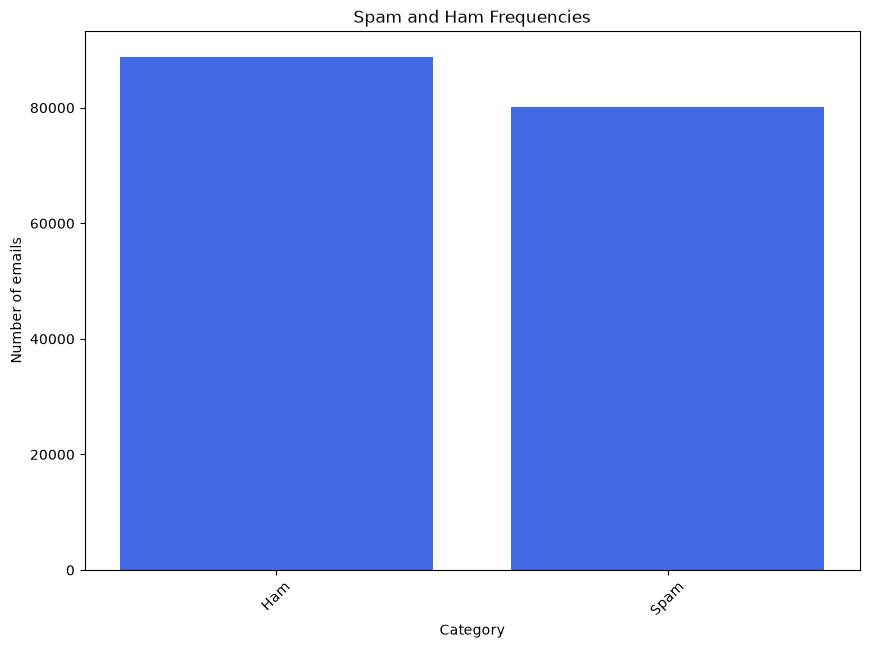

In [6]:
# getting to know the data with spam to ham frequencies as a bar graph 
category_counts = df['label'].value_counts()
plt.figure(figsize=(10,7))
plt.bar(category_counts.index, category_counts.values, color='royalblue')
plt.title('Spam and Ham Frequencies')
plt.xticks(rotation=45) # Rotate labels to avoid overlap
plt.ylabel("Number of emails")
plt.xlabel("Category")
plt.show()

In [7]:
# top 20 most common words in spam 
spam_column = df[df["label"] == "Spam"]
spam_text_column = spam_column["text"]

all_spam_words = []
for email in spam_text_column:
    all_spam_words.extend(clean(email))

most_common_spam_words = Counter(all_spam_words).most_common(20)

# top 20 most common words in ham
ham_column = df[df["label"] == "Ham"]
ham_text_column = ham_column["text"]

all_ham_words = []
for email in ham_text_column:
    all_ham_words.extend(clean(email))

most_common_ham_words = Counter(all_ham_words).most_common(20)



In [8]:
spam_email_lengths = [len(clean(email)) for email in spam_text_column]
ham_email_lengths = [len(clean(email)) for email in ham_text_column]

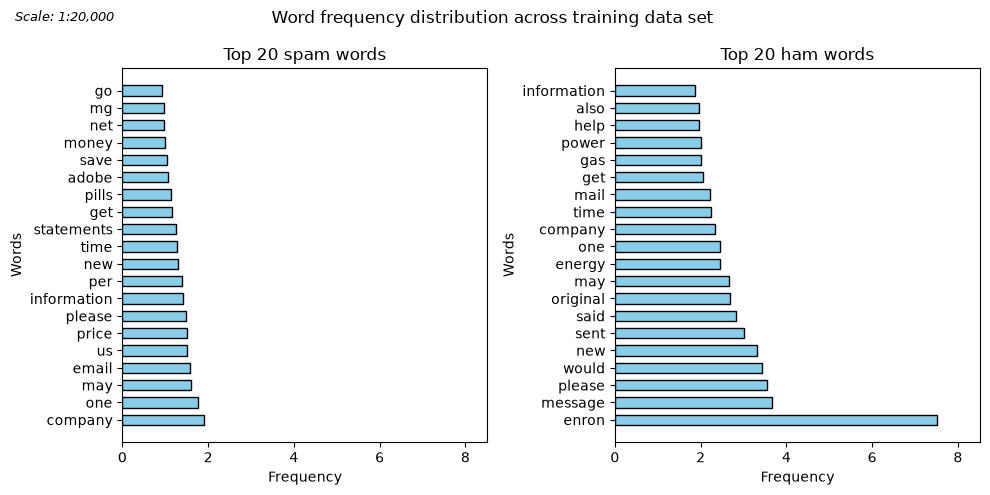

In [13]:
y_labels = [item[0] for item in most_common_spam_words]
x_values = [item[1] for item in most_common_spam_words]

yham_labels = [item[0] for item in most_common_ham_words]
xham_values = [item[1] for item in most_common_ham_words]

max_val = max(max(x_values), max(xham_values))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Word frequency distribution across training data set ")

scale = 20000
max_val = (max(max(x_values), max(xham_values)) + scale) / scale

axes[0].barh(y_labels, [v / scale for v in x_values], color='skyblue', edgecolor='black', height=0.6)
axes[0].set_title('Top 20 spam words')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')
axes[0].set_xlim(0, max_val )

axes[1].barh(yham_labels, [v / scale for v in xham_values], color='skyblue', edgecolor='black', height=0.6)
axes[1].set_title('Top 20 ham words')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')
axes[1].set_xlim(0, max_val)

fig.text(0.02, 0.98, 'Scale: 1:20,000', ha='left', va='top', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

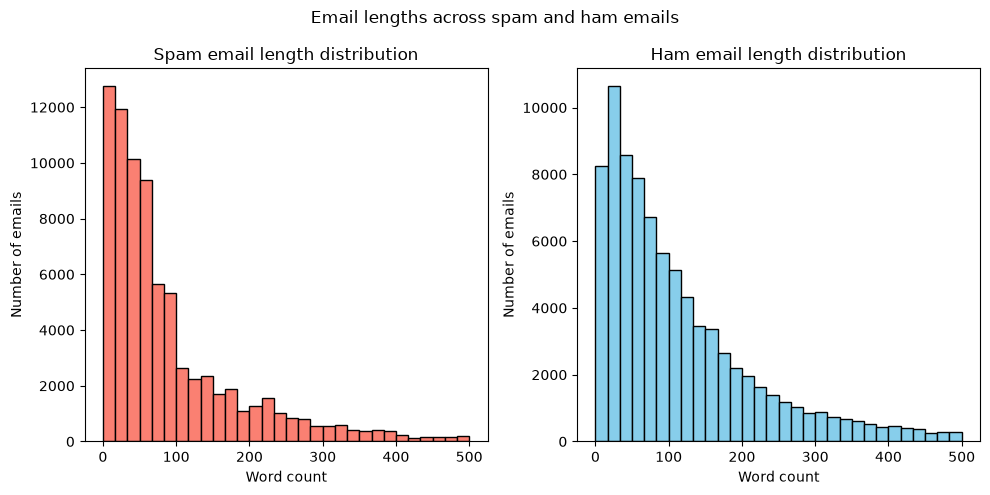

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Email lengths across spam and ham emails")

axes[0].hist(spam_email_lengths, bins=30, range = (0, 500), color='salmon', edgecolor='black')
axes[0].set_title('Spam email length distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of emails')

axes[1].hist(ham_email_lengths, bins=30, range = (0, 500), color='skyblue', edgecolor='black')
axes[1].set_title('Ham email length distribution')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Number of emails')

plt.tight_layout()
plt.show()

In [25]:
ham_data = np.array(ham_email_lengths)
spam_data = np.array(spam_email_lengths)

ham_mean = round(np.mean(ham_data), 2)
ham_median = round(np.median(ham_data), 2)
ham_mode = Counter(ham_email_lengths).most_common(1)[0]

print(f"Ham mean: {ham_mean}\nHam median: {ham_median}\nHam mode: {ham_mode[0]}:{ham_mode[1]}")
print("=" * 20)

spam_mean = round(np.mean(spam_data), 2)
spam_median = round(np.median(spam_data), 2)
spam_mode = Counter(spam_email_lengths).most_common(1)[0]

print(f"Spam mean: {spam_mean}\nSpam median: {spam_median}\nSpam mode: {spam_mode[0]}:{spam_mode[1]}")

Ham mean: 211.45
Ham median: 90.0
Ham mode: 21:1010
Spam mean: 116.95
Spam median: 57.0
Spam mode: 22:1005
